# Adversarial Search & Games

## Local Search Overview

## Game class

We start with defining the *abstract* `class Game`.

We rely on, but do not define yet, the concept of a **state of the game** --> the individual games (derived classes from this one) should define states.

For now, all we require is that a state has a `state.to_move` attribute, which gives the *name of the player whose turn it is*.

"Name" will be something like 'X' or 'O' for tic-tac-toe.

In [1]:
from src.gameClass import Game

In [2]:
help(Game)

Help on class Game in module src.gameClass:

class Game(builtins.object)
 |  A game is similar to a problem, but it has a terminal test instead of
 |  a goal test, and a utility for each terminal state. To create a game,
 |  subclass this class and implement `actions`, `result`, `is_terminal`,
 |  and `utility`. You will also need to set the .initial attribute to the
 |  initial state; this can be done in the constructor.
 |
 |  Methods defined here:
 |
 |  actions(self, state)
 |      Return a collection of the allowable moves from this state.
 |
 |  is_terminal(self, state)
 |      Return True if this is a final state for the game.
 |
 |  result(self, state, move)
 |      Return the state that results from making a move from a state.
 |
 |  utility(self, state, player)
 |      Return the value of this final state to player.
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  __dict__
 |      dictionary for instance v

## How to play

We also define `play_game`, which 
* takes a game and a dictionary of `{player_name: strategy_function}` pairs, 
* and plays out the game, 
    * on each turn checking `state.to_move` to see whose turn it is, 
    * and then getting the `strategy` function for that player and applying it to the game and the state to get a move.

In [3]:
from src.gameClass import play_game

In [4]:
help(play_game)

Help on function play_game in module src.gameClass:

play_game(game, strategies: dict, verbose=False)
    Play a turn-taking game. `strategies` is a {player_name: function} dict,
    where function(state, game) is used to get the player's move.



## Minimax-Based Game Search Algorithm

Given a game tree, the optimal strategy can be determined by working out the
**minimax value **of each state in the tree:

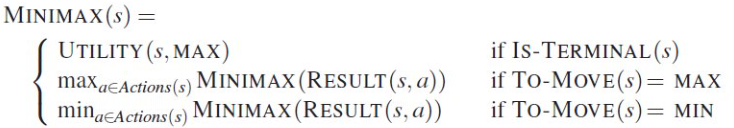

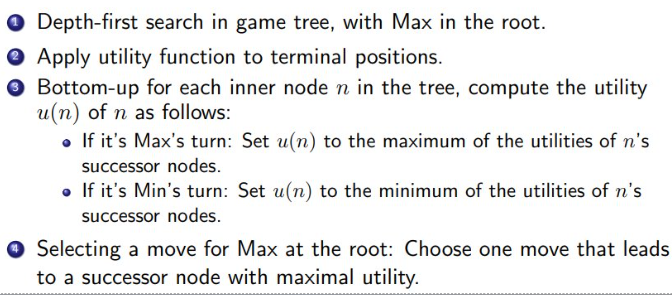

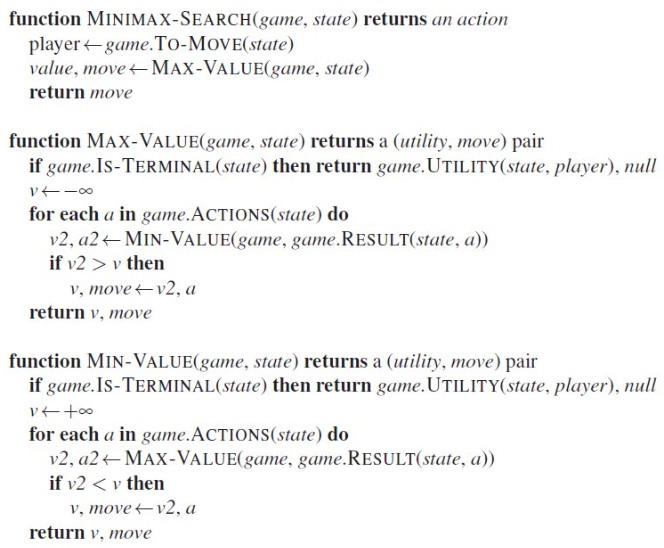

A game search algorithm takes 2 inputs:
* the game we are playing 
* and the current state of the game, 

and returns a `(value, move)` pair, where `value` is the *utility* that the algorithm computes for the player whose turn it is to move, and *move* is the move itself.

The **minimax_search**, which exhaustively searches the game tree to find an optimal move (assuming both players play optimally)

In [6]:
from src.algorithms import minimax_search

In [6]:
help(minimax_search)

Help on function minimax_search in module src.algorithms:

minimax_search(game, state)
    Search game tree to determine best move; return (value, move) pair.



## Tic-Tac-Toe Example

We have the notion of an abstract game, we have some search functions.

Now it is time to define a real game; a simple one, *tic-tac-toe*. 

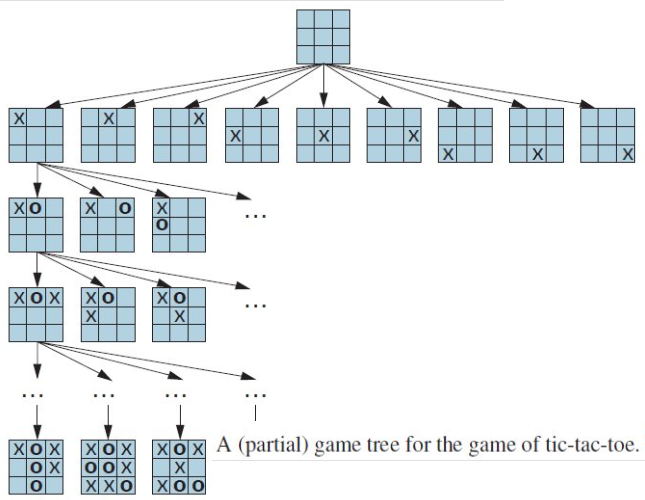

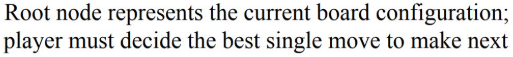

`Moves` are `(x, y)` pairs denoting squares, where (0, 0) is the top left, and (2, 2) is the bottom right (on a board of size height=width=3).

### Game State

States in tic-tac-toe (and other games) will be represented as a **Board**, which in general will consist of *{(x, y): contents}* pairs.

For example *{(0, 0): 'X', (0 1): 'O'}* might be the state of the board after 2 moves

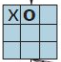



A **Board**, which is a subclass of defaultdict.

Besides the contents of squares, a board also has some attributes:

* `.to_move `to name the player whose move it is;
* `.width` and *.height* to give the size of the board (both 3 in tic-tac-toe, but other numbers in related games);
* possibly other attributes, as specified by keywords.

In [7]:
from src.boardClass import Board

In [8]:
help(Board)

Help on class Board in module src.boardClass:

class Board(collections.defaultdict)
 |  Board(width=8, height=8, to_move=None, **kwds)
 |
 |  A board has the player to move, a cached utility value,
 |  and a dict of {(x, y): player} entries, where player is 'X' or 'O'.
 |
 |  Method resolution order:
 |      Board
 |      collections.defaultdict
 |      builtins.dict
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __hash__(self)
 |      Return hash(self).
 |
 |  __init__(self, width=8, height=8, to_move=None, **kwds)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  __missing__(self, loc)
 |      __missing__(key) # Called by __getitem__ for missing key; pseudo-code:
 |      if self.default_factory is None: raise KeyError((key,))
 |      self[key] = value = self.default_factory()
 |      return value
 |
 |  __repr__(self)
 |      Return repr(self).
 |
 |  new(self, changes: dict, **kwds) -> 'Board'
 |      Given a dict of {(x, y): contents} change

As a defaultdict, the Board class has 
* a` __missing__` method, which returns *empty* for squares that have no been assigned but are within the width × height boundaries, or *off* otherwise. 
* a `__hash__` method, so instances can be stored in hash tables.

### Players

We represent a **player** as a **callable** that will be passed 2 arguments: `(game, state)` and will return a `move`. 

The function player creates a player out of a search algorithm - > to simulate that a player has (plays based on) a **strategy**.

But you can create your own players as functions, as is done with `random_player` below.

In [5]:
from src.players import smart_player,random_player

In [10]:
help(smart_player)

Help on function smart_player in module src.players:

smart_player(search_algorithm)
    A game player who uses the specified search algorithm



In [13]:
help(random_player)

Help on function random_player in module src.players:

random_player(game, state)
    A game player who  uses random choice to do a next move



### Let's Play a Game

We're ready to play a game. 

We'll set up a match between a **random_player** (who chooses randomly from the legal moves) and a **player(minimax_search)**. 

We will see that the smart player(minimax_search) will never lose, but if random_player is lucky, it will be a tie.

In [14]:
from src.TicTacToeGameClass import TicTacToe

In [15]:
play_game(TicTacToe(), dict(X=random_player, O= smart_player(minimax_search)), verbose=True).utility

Player X move: (2, 1)
. . .
. . X
. . .

Player O move: (0, 1)
. . .
O . X
. . .

Player X move: (1, 1)
. . .
O X X
. . .

Player O move: (0, 0)
O . .
O X X
. . .

Player X move: (0, 2)
O . .
O X X
X . .

Player O move: (2, 0)
O . O
O X X
X . .

Player X move: (1, 0)
O X O
O X X
X . .

Player O move: (1, 2)
O X O
O X X
X O .

Player X move: (2, 2)
O X O
O X X
X O X



0

The random player could stumble into a draw (0)

## Task: 5 misery game

This is our simplified version of the "21" Counting/Drinking Game, that is is likely a variation of a simple counting game where the goal is to force another player to say the number 21 (5 in our version). 

The general rules as follows: 
* **Objective**: The goal is to avoid being the player who says the number "5" (or the greater one).
* **Gameplay**: Players take turns counting from 1 upwards (The game counter starts at 1).
* **Counting Rules**: Each player can say only 1, 2, or 3 consecutive numbers in their turn.
* **Losing**: The player who is forced to say "5" (or a number greater than 5) loses the round.

Tasks:
1. Define the search problem associated with the 2-player version
* Initial state - ?
* Player function - ?
* Actions - ?
* Transition model - ?
* Terminal test -?
* Utility function -?
2. Develop the Gane using the Minimax algorithm as a strategy for the SmartPlayer
3. Test (play the game) with :
* the SmartPlayer vs RandomPlayer
* the SmartPlayer vs Human

See the example of the Game below:

In [1]:
from src.algorithms import minimax_search
from src.gameClass import play_game1
from src.FiveMiseryGameClass import FiveMisery
from src.players import smart_player,random_player



In [15]:
gameresult=play_game1(FiveMisery(), dict(X=random_player, O= smart_player(minimax_search)), verbose=True).utility
gameresult

Round 1
The Player X is thinking ....
Player X move: 1
The counter: 2
Round 2
The Player O is thinking ....
Player O move: 1
The counter: 3
Round 3
The Player X is thinking ....
Player X move: 2
The counter: 5
O is a winner!
Game over


1